
═══════════════  REPORTE  LCU  JERÁRQUICO  RECURSIVO  ════════════════
  Sistema : Hamiltoniano de Ising Transverso 4 qubits
  Tamaño  : N = 16  (4 qubits / niveles de recursión)
  Hermítica: ✓  Sí
  Norma ‖M‖_F    : 8.000000
  Norma ‖M‖_2    : 3.427034
  Rango espectral: [-3.4270,  3.4270]

  Coeficientes β activos : 7 / 256  (2.7 %)
  Error Frobenius total  : 0.0000e+00   ✓ EXACTO



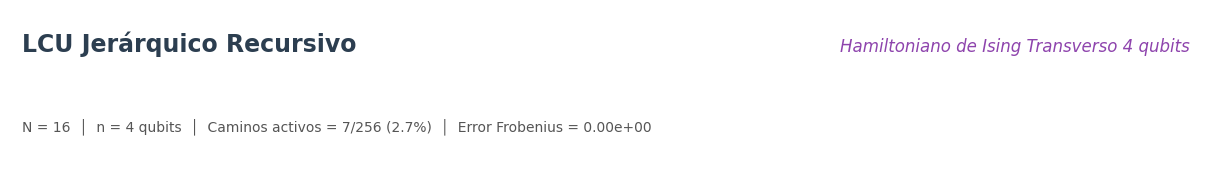


─────  SECCIÓN 3 · VALIDACIÓN  —  M original vs M reconstruida  ──────

  ‖M - M_rec‖_F          = 0.0000e+00
  ‖M‖_F                  = 8.000000
  Error relativo         = 0.0000e+00   ✓ EXACTO (< 1e-10)
  max |residuo|          = 0.0000e+00
  Hermitiana M_rec:      ✓


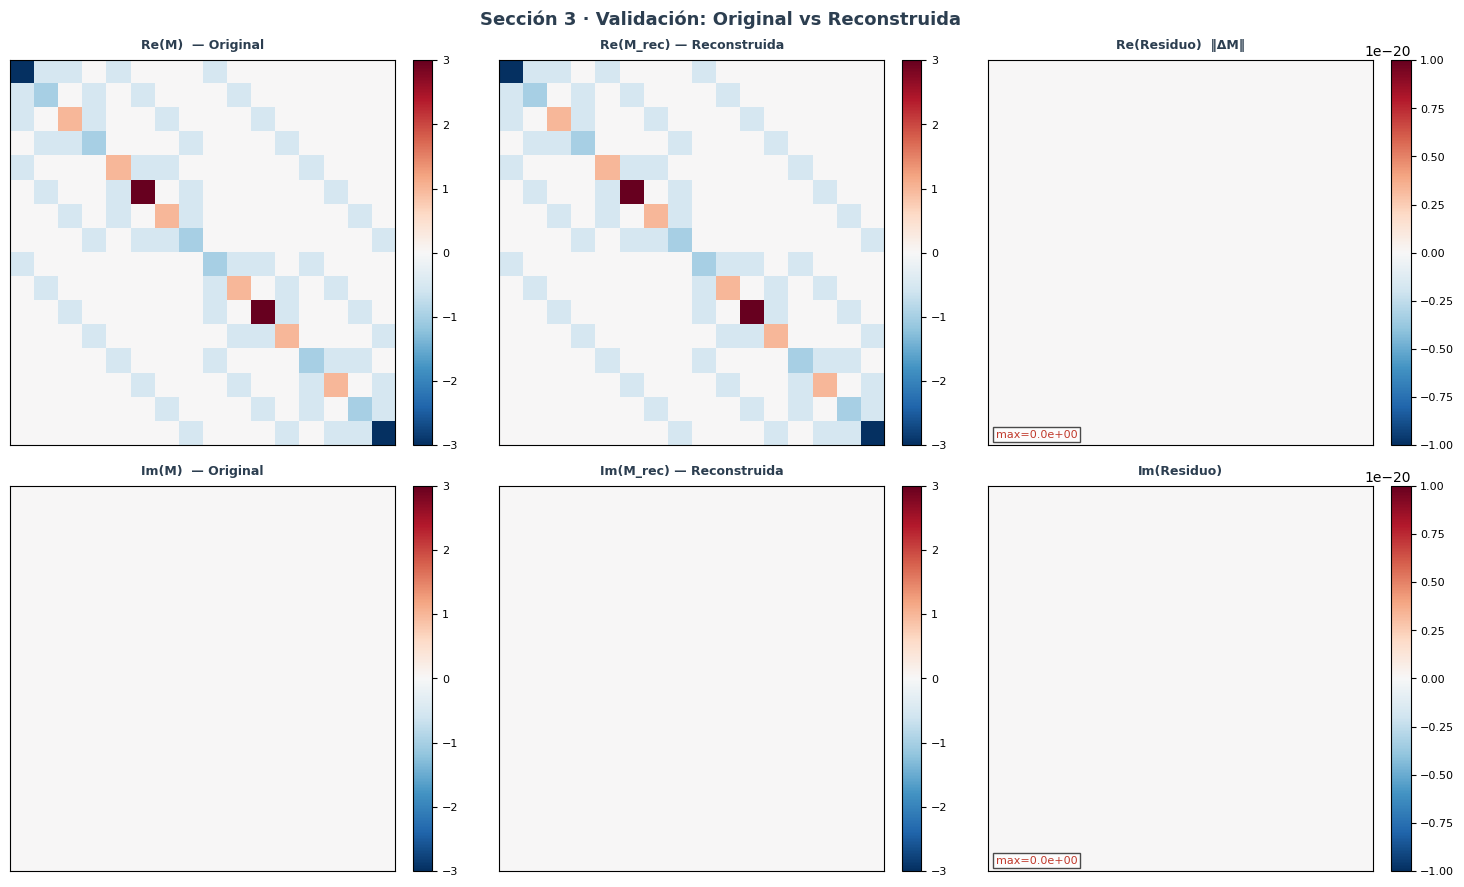


  SECCIÓN 4 · ESTADÍSTICAS  —  Distribución β y activación por nivel  

  Estadísticas del tensor β

  Métrica           Valor             % total           Nota            
  ────────────────  ────────────────  ────────────────  ────────────────
  Total posible     256               —                 —               
  Activos           7                 2.7%              —               
  max |β|           1.000000          —                 —               
  min |β|           0.500000          —                 —               
  media |β|         0.714286          —                 —               
  mediana |β|       0.500000          —                 —               
  std |β|           0.247436          —                 —               
  p25 |β|           0.500000          —                 —               
  p75 |β|           1.000000          —                 —               
  p90 |β|           1.000000          —                 —               

  Energía Σ|β| por ni

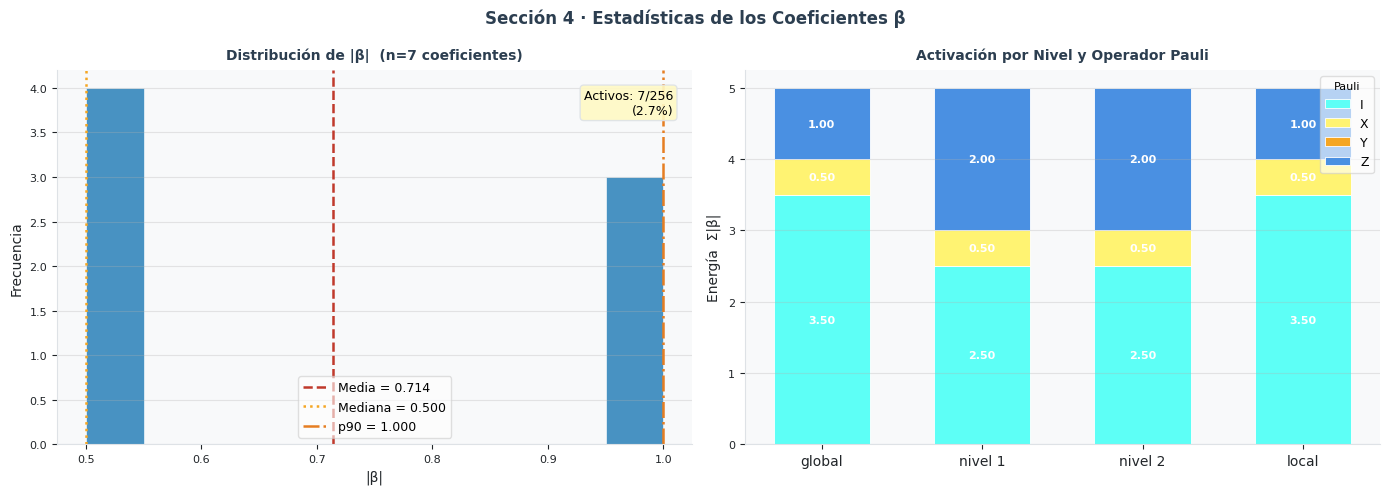


───  SECCIÓN 5 · COMPRESIÓN  —  Error vs. coeficientes retenidos  ────

  Tabla de compresión por percentil

  Percentil      Umbral |β|     Activos        Zerados%       Error Fro.     Estado       
  ─────────────  ─────────────  ─────────────  ─────────────  ─────────────  ─────────────
  p00            0.500000          3             57.1%        5.0000e-01     ✗            
  p10            0.500000          3             57.1%        5.0000e-01     ✗            
  p25            0.500000          3             57.1%        5.0000e-01     ✗            
  p50            0.500000          3             57.1%        5.0000e-01     ✗            
  p75            1.000000          0            100.0%        1.0000e+00     ✗            
  p90            1.000000          0            100.0%        1.0000e+00     ✗            
  p95            1.000000          0            100.0%        1.0000e+00     ✗            
  p99            1.000000          0            100.0%        1.0000e+0

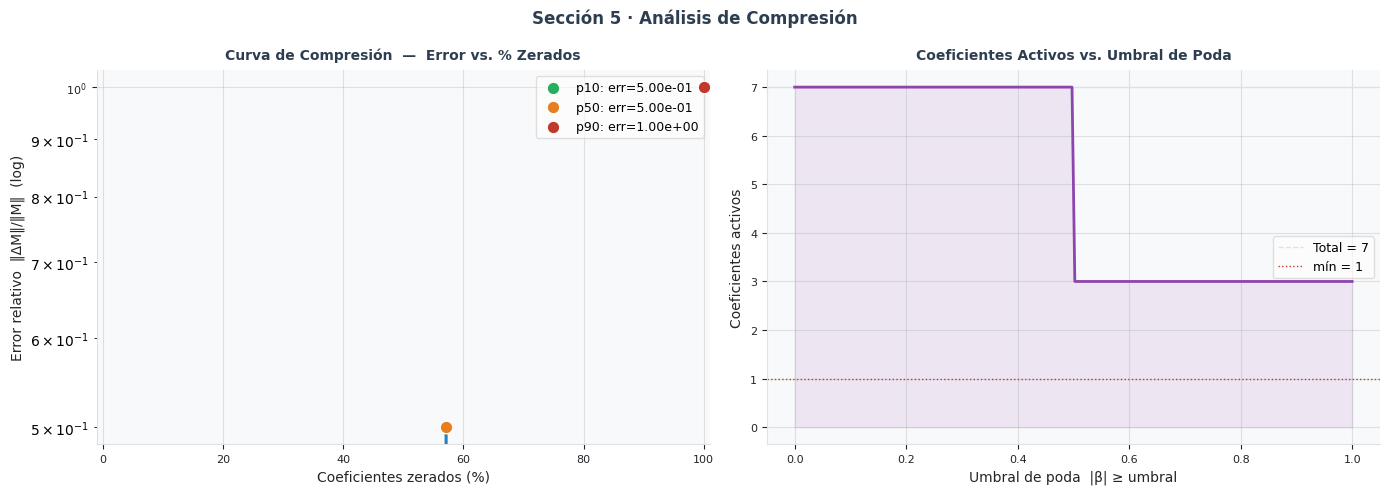


───────────────  SECCIÓN 6 · ÁRBOL RECURSIVO DE PAULI  ───────────────


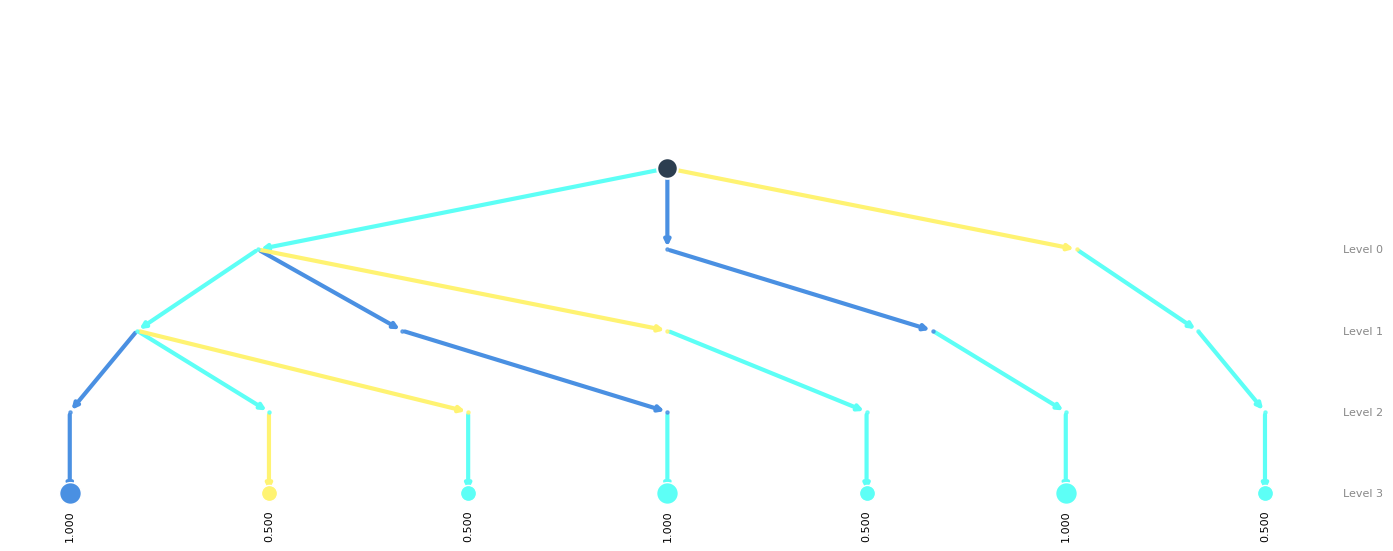


════════════════════════  REPORTE COMPLETADO  ════════════════════════
  Hamiltoniano de Ising Transverso 4 qubits  ·  N=16  ·  n=4 qubits
  Caminos activos : 7 / 256
  Error Frobenius : 0.0000e+00  ✓



In [3]:
"""
LCU Jerárquico Recursivo — Reporte Completo para Google Colab
=============================================================
Ejecuta este archivo en Google Colab (o Jupyter) para obtener un reporte
visual completo con tablas y gráficas en consola, célula por célula.

Estructura del reporte (5 figuras + salida de texto):

  [SECCIÓN 1]  Encabezado e información del sistema
  [SECCIÓN 2]  Descomposición: tabla de caminos de Pauli + heatmap β
  [SECCIÓN 3]  Validación: M original vs M_rec + error elemento a elemento
  [SECCIÓN 4]  Estadísticas: tabla resumen + distribución |β| + activación por nivel
  [SECCIÓN 5]  Compresión: tabla de percentiles + curva error vs. % zerados
  [SECCIÓN 6]  Árbol de Pauli completo (grafo jerárquico)

Uso en Colab:
    !pip install networkx -q
    exec(open('lcu_colab_reporte.py').read())
    # — o bien —
    from lcu_colab_reporte import reporte_completo
    reporte_completo(M, n=3, titulo="Mi Hamiltoniano")
"""

# ─────────────────────────────────────────────────────────────────────────────
# Imports
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from collections import defaultdict
import numpy as np
from functools import reduce
import csv
import zipfile
import os


try:
    import networkx as nx
    _HAS_NX = True
except ImportError:
    _HAS_NX = False




def _reconstruir(beta: dict, n: int) -> np.ndarray:
    N = 2**n; M = np.zeros((N,N), dtype=complex)
    for camino, val in beta.items():
        indices = list(reversed(camino)); t = PAULIS[indices[0]]
        for idx in indices[1:]: t = np.kron(t, PAULIS[idx])
        M += val * t
    return M

def _escribir_csv(ruta: str, cabeceras: list, filas: list) -> int:
    """Escribe un CSV y retorna el número de filas escritas."""
    with open(ruta, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=cabeceras)
        w.writeheader()
        for fila in filas:
            w.writerow(fila)
    return len(filas)
# ═════════════════════════════════════════════════════════════════════════════
# FUNCIÓN PRINCIPAL
# ═════════════════════════════════════════════════════════════════════════════

def guardar_csv_reporte(
    M          : np.ndarray,
    beta       : dict,
    n          : int,
    titulo     : str  = "",
    directorio : str  = ".",
    n_puntos_compresion: int = 200,
    prefijo    : str  = "lcu",
) -> dict:
    """
    Extrae y guarda en CSV todos los datos visualizados en las 6 secciones
    del reporte LCU (lcu_colab_reporte.py).

    Parámetros
    ----------
    M          : matriz original 2ⁿ×2ⁿ
    beta       : dict producido por descomponer()
    n          : número de qubits
    titulo     : nombre del sistema (se incluye en sec1_resumen.csv)
    directorio : carpeta de salida. En Colab usa '/content'
    n_puntos_compresion : puntos del barrido de la curva de compresión
    prefijo    : prefijo de los nombres de archivo

    Archivos generados
    ------------------
    {prefijo}_sec1_resumen.csv      — [Sección 1] métricas globales
    {prefijo}_sec2_caminos.csv      — [Sección 2] todos los caminos β
    {prefijo}_sec3_residuo.csv      — [Sección 3] M, M_rec, residuo por elemento
    {prefijo}_sec4_estadisticas.csv — [Sección 4] estadísticas |β| + energía niveles
    {prefijo}_sec5_compresion.csv   — [Sección 5] curva error vs. compresión
    {prefijo}_reporte_completo.zip  — ZIP con los 5 CSV anteriores

    Retorna
    -------
    rutas : dict { clave → ruta absoluta del archivo }
    """
    os.makedirs(directorio, exist_ok=True)
    N        = 2 ** n
    M_rec    = _reconstruir(beta, n)
    M_norm   = float(np.linalg.norm(M, "fro"))
    err_total = _error_fro(M, M_rec)
    residuo  = M - M_rec
    eigs     = np.linalg.eigvalsh(M)
    betas_abs = np.array([abs(v) for v in beta.values()])

    rutas = {}

    # ─────────────────────────────────────────────────────────────────────────
    # SEC 1 — Resumen global del sistema
    # ─────────────────────────────────────────────────────────────────────────
    ruta = os.path.join(directorio, f"{prefijo}_sec1_resumen.csv")
    filas_1 = [
        {"metrica": "titulo",            "valor": titulo},
        {"metrica": "n_qubits",          "valor": n},
        {"metrica": "N",                 "valor": N},
        {"metrica": "es_hermitica",      "valor": bool(np.allclose(M, M.conj().T, atol=1e-10))},
        {"metrica": "norma_frobenius",   "valor": M_norm},
        {"metrica": "norma_espectral",   "valor": float(np.linalg.norm(M, 2))},
        {"metrica": "eigenval_min",      "valor": float(eigs.min())},
        {"metrica": "eigenval_max",      "valor": float(eigs.max())},
        {"metrica": "rango_espectral",   "valor": float(eigs.max() - eigs.min())},
        {"metrica": "beta_activos",      "valor": len(beta)},
        {"metrica": "beta_total_posible","valor": 4**n},
        {"metrica": "beta_sparsity_pct", "valor": round(len(beta)/4**n*100, 4)},
        {"metrica": "error_frobenius",   "valor": err_total},
        {"metrica": "es_exacto",         "valor": err_total < 1e-10},
        {"metrica": "max_residuo",       "valor": float(np.abs(residuo).max())},
    ]
    n1 = _escribir_csv(ruta, ["metrica", "valor"], filas_1)
    rutas["sec1_resumen"] = ruta
    print(f"  ✓ sec1_resumen.csv       ({n1} filas)")

    # ─────────────────────────────────────────────────────────────────────────
    # SEC 2 — Caminos de Pauli con coeficientes β
    # ─────────────────────────────────────────────────────────────────────────
    ruta = os.path.join(directorio, f"{prefijo}_sec2_caminos.csv")
    items = sorted(beta.items(), key=lambda kv: abs(kv[1]), reverse=True)
    filas_2 = []
    for rank, (camino, val) in enumerate(items, 1):
        # Construir etiqueta textual y columnas por nivel
        etiq = "⊗".join(ETIQUETAS[mu] for mu in camino)
        fila = {
            "rank"       : rank,
            "camino"     : etiq,
            "beta_abs"   : float(abs(val)),
            "beta_real"  : float(val.real),
            "beta_imag"  : float(val.imag),
        }
        # Una columna por nivel: nivel_0, nivel_1, ..., nivel_{n-1}
        for nivel in range(n):
            fila[f"pauli_nivel_{nivel}"] = ETIQUETAS[camino[nivel]]
        filas_2.append(fila)

    cabeceras_2 = ["rank", "camino", "beta_abs", "beta_real", "beta_imag"] + \
                  [f"pauli_nivel_{i}" for i in range(n)]
    n2 = _escribir_csv(ruta, cabeceras_2, filas_2)
    rutas["sec2_caminos"] = ruta
    print(f"  ✓ sec2_caminos.csv       ({n2} filas  = {n2} caminos activos)")

    # ─────────────────────────────────────────────────────────────────────────
    # SEC 3 — Matrices M, M_rec y residuo (element-wise)
    # ─────────────────────────────────────────────────────────────────────────
    ruta = os.path.join(directorio, f"{prefijo}_sec3_residuo.csv")
    filas_3 = []
    for i in range(N):
        for j in range(N):
            filas_3.append({
                "fila"        : i,
                "columna"     : j,
                "M_real"      : float(M[i,j].real),
                "M_imag"      : float(M[i,j].imag),
                "M_rec_real"  : float(M_rec[i,j].real),
                "M_rec_imag"  : float(M_rec[i,j].imag),
                "residuo_real": float(residuo[i,j].real),
                "residuo_imag": float(residuo[i,j].imag),
                "residuo_abs" : float(abs(residuo[i,j])),
            })
    n3 = _escribir_csv(ruta,
        ["fila","columna","M_real","M_imag","M_rec_real","M_rec_imag",
         "residuo_real","residuo_imag","residuo_abs"],
        filas_3)
    rutas["sec3_residuo"] = ruta
    print(f"  ✓ sec3_residuo.csv       ({n3} filas  = {N}×{N} elementos)")

    # ─────────────────────────────────────────────────────────────────────────
    # SEC 4 — Estadísticas de |β| y energía por nivel/Pauli
    # ─────────────────────────────────────────────────────────────────────────
    ruta = os.path.join(directorio, f"{prefijo}_sec4_estadisticas.csv")
    energia = _energia_niveles(beta, n)

    # Hoja 1: estadísticas escalares de |β|
    filas_4_stats = [
        {"tabla": "beta_stats", "metrica": "total_posible",   "valor": float(4**n), "unidad": "coef"},
        {"tabla": "beta_stats", "metrica": "activos",          "valor": float(len(beta)), "unidad": "coef"},
        {"tabla": "beta_stats", "metrica": "sparsity_pct",     "valor": round(len(beta)/4**n*100, 4), "unidad": "%"},
        {"tabla": "beta_stats", "metrica": "max_beta",         "valor": float(betas_abs.max()), "unidad": "—"},
        {"tabla": "beta_stats", "metrica": "min_beta",         "valor": float(betas_abs.min()), "unidad": "—"},
        {"tabla": "beta_stats", "metrica": "media_beta",       "valor": float(betas_abs.mean()), "unidad": "—"},
        {"tabla": "beta_stats", "metrica": "mediana_beta",     "valor": float(np.median(betas_abs)), "unidad": "—"},
        {"tabla": "beta_stats", "metrica": "std_beta",         "valor": float(betas_abs.std()), "unidad": "—"},
        {"tabla": "beta_stats", "metrica": "p25_beta",         "valor": float(np.percentile(betas_abs,25)), "unidad": "—"},
        {"tabla": "beta_stats", "metrica": "p75_beta",         "valor": float(np.percentile(betas_abs,75)), "unidad": "—"},
        {"tabla": "beta_stats", "metrica": "p90_beta",         "valor": float(np.percentile(betas_abs,90)), "unidad": "—"},
    ]

    # Hoja 2: energía Σ|β| por (nivel, Pauli)
    filas_4_energia = []
    for nivel in range(n):
        rol = "global" if nivel == 0 else ("local" if nivel == n-1 else f"nivel_{nivel}")
        for mu in range(4):
            filas_4_energia.append({
                "tabla"      : "energia_niveles",
                "metrica"    : f"nivel_{nivel}_{ETIQUETAS[mu]}",
                "valor"      : float(energia[nivel, mu]),
                "unidad"     : "Σ|β|",
            })
        filas_4_energia.append({
            "tabla"   : "energia_niveles",
            "metrica" : f"nivel_{nivel}_TOTAL",
            "valor"   : float(energia[nivel].sum()),
            "unidad"  : "Σ|β|",
        })

    filas_4 = filas_4_stats + filas_4_energia
    n4 = _escribir_csv(ruta, ["tabla", "metrica", "valor", "unidad"], filas_4)
    rutas["sec4_estadisticas"] = ruta
    print(f"  ✓ sec4_estadisticas.csv  ({n4} filas  = stats + energía por nivel)")

    # ─────────────────────────────────────────────────────────────────────────
    # SEC 5 — Curva de compresión (error vs. umbral)
    # ─────────────────────────────────────────────────────────────────────────
    ruta = os.path.join(directorio, f"{prefijo}_sec5_compresion.csv")
    mags_ord = sorted([abs(v) for v in beta.values()])
    max_mag  = mags_ord[-1] if mags_ord else 1.0
    umbrales = np.linspace(0, max_mag * 0.9995, n_puntos_compresion)

    filas_5 = []
    for punto, u in enumerate(umbrales):
        bp       = {k: v for k, v in beta.items() if abs(v) > u}
        n_act    = len(bp)
        spars    = n_act / max(len(beta), 1)
        tz       = (1.0 - spars) * 100.0
        err      = _error_fro(M, _reconstruir(bp, n)) if bp else 1.0
        filas_5.append({
            "punto"           : punto,
            "umbral_epsilon"  : float(u),
            "n_activos"       : n_act,
            "sparsity_pct"    : round(spars * 100, 6),
            "zerados_pct"     : round(tz, 6),
            "error_frobenius" : err,
        })

    n5 = _escribir_csv(ruta,
        ["punto","umbral_epsilon","n_activos","sparsity_pct",
         "zerados_pct","error_frobenius"],
        filas_5)
    rutas["sec5_compresion"] = ruta
    print(f"  ✓ sec5_compresion.csv    ({n5} filas  = {n5} puntos del barrido)")

    # ─────────────────────────────────────────────────────────────────────────
    # ZIP — todos los CSV en un solo archivo
    # ─────────────────────────────────────────────────────────────────────────
    ruta_zip = os.path.join(directorio, f"{prefijo}_reporte_completo.zip")
    with zipfile.ZipFile(ruta_zip, "w", zipfile.ZIP_DEFLATED) as zf:
        for clave, r in rutas.items():
            zf.write(r, arcname=os.path.basename(r))
    rutas["zip"] = ruta_zip

    # ─────────────────────────────────────────────────────────────────────────
    # Resumen final en consola
    # ─────────────────────────────────────────────────────────────────────────
    print(f"\n  ─────────────────────────────────────────")
    print(f"  Guardado en: {os.path.abspath(directorio)}")
    print(f"  ZIP:  {os.path.basename(ruta_zip)}"
          f"  ({os.path.getsize(ruta_zip)/1024:.1f} KB)")
    total_filas = n1 + n2 + n3 + n4 + n5
    print(f"  Total filas exportadas: {total_filas:,}")
    print(f"  ─────────────────────────────────────────")

    return rutas


# ─────────────────────────────────────────────────────────────────────────────
# Paleta — compatible con fondo blanco de Colab
# ─────────────────────────────────────────────────────────────────────────────
C = {
    "bg"      : "#ffffff",
    "panel"   : "#f8f9fa",
    "borde"   : "#dee2e6",
    "texto"   : "#212529",
    "acento"  : "#2c3e50",
    "I"       : "#5DFFF6",
    "X"       : "#FFF372",
    "Y"       : "#F5A623",
    "Z"       : "#4A90E2",
    "ok"      : "#27ae60",
    "warn"    : "#e67e22",
    "err"     : "#c0392b",
    "grad1"   : "#2980b9",
    "grad2"   : "#8e44ad",
}

PAULIS = np.array([
    [[1,  0 ], [0,  1 ]],
    [[0,  1 ], [1,  0 ]],
    [[0, -1j], [1j, 0 ]],
    [[1,  0 ], [0, -1 ]],
], dtype=complex)

ETIQUETAS    = ["I", "X", "Y", "Z"]
PAULI_COLORS = [C["I"], C["X"], C["Y"], C["Z"]]


# ═════════════════════════════════════════════════════════════════════════════
# NÚCLEO ALGORÍTMICO
# ═════════════════════════════════════════════════════════════════════════════

def descomponer(M: np.ndarray, epsilon: float = 1e-12) -> dict:
    """Descomposición LCU jerárquica recursiva → dict {camino: β}."""
    N = M.shape[0]
    assert N > 0 and (N & (N - 1)) == 0
    if N == 2:
        beta = {}
        for mu in range(4):
            val = 0.5 * np.trace(M @ PAULIS[mu])
            if abs(val) > epsilon:
                beta[(mu,)] = val
        return beta
    L = N // 2
    beta_arbol = {}
    for mu in range(4):
        A_mu = np.zeros((L, L), dtype=complex)
        for i in range(L):
            for j in range(L):
                bloque = M[i*2:(i+1)*2, j*2:(j+1)*2]
                A_mu[i, j] = 0.5 * np.trace(bloque @ PAULIS[mu])
        if np.linalg.norm(A_mu) <= epsilon:
            continue
        sub = descomponer(A_mu, epsilon)
        for camino_sub, val in sub.items():
            beta_arbol[(mu,) + camino_sub] = val
    return beta_arbol


def reconstruir(beta: dict, n: int) -> np.ndarray:
    """Reconstrucción: P[camino[-1]] ⊗ … ⊗ P[camino[0]]."""
    N = 2 ** n
    M_total = np.zeros((N, N), dtype=complex)
    for camino, val in beta.items():
        indices = list(reversed(camino))
        t = PAULIS[indices[0]]
        for idx in indices[1:]:
            t = np.kron(t, PAULIS[idx])
        M_total += val * t
    return M_total

def _error_fro_(M, M_rec):
    # Añadido chequeo de seguridad para evitar divisiones por cero o errores de tipo
    try:
        diff_norm = np.linalg.norm(M - M_rec, "fro")
        m_norm = np.linalg.norm(M, "fro")
        return float(diff_norm / m_norm) if m_norm > 1e-15 else float(diff_norm)
    except Exception:
        return 1.0 # Error máximo si falla la comparación

def _error_fro(M, M_rec):
    d = np.linalg.norm(M - M_rec, "fro")
    n = np.linalg.norm(M, "fro")
    return float(d / n) if n > 1e-15 else float(d)


def _beta_mat(beta: dict, n: int) -> np.ndarray:
    """Reorganiza β en matriz (4^(n-1), 4)."""
    mat = np.zeros((4 ** (n - 1), 4))
    for camino, val in beta.items():
        fila = 0
        for mu in camino[:-1]:
            fila = fila * 4 + mu
        mat[fila, camino[-1]] = abs(val)
    return mat


def _etiq_prefijo(idx: int, longitud: int) -> str:
    e = []
    for _ in range(longitud):
        e.append(ETIQUETAS[idx % 4])
        idx //= 4
    return "⊗".join(reversed(e)) if e else "—"


def _energia_niveles(beta: dict, n: int) -> np.ndarray:
    mat = np.zeros((n, 4))
    for camino, val in beta.items():
        for nivel, mu in enumerate(camino):
            mat[nivel, mu] += abs(val)
    return mat


# ═════════════════════════════════════════════════════════════════════════════
# HELPERS DE ESTILO
# ═════════════════════════════════════════════════════════════════════════════

def _sep(titulo: str, ancho: int = 70, simbolo: str = "═"):
    pad = max(0, ancho - len(titulo) - 4)
    izq = pad // 2
    der = pad - izq
    print(f"\n{simbolo * izq}  {titulo}  {simbolo * der}")


def _tabla_texto(filas: list, cabeceras: list, ancho_col: int = 14):
    """Imprime una tabla alineada en consola."""
    fmt = "  ".join(f"{{:<{ancho_col}}}" for _ in cabeceras)
    sep_line = "  ".join("─" * ancho_col for _ in cabeceras)
    print("  " + fmt.format(*cabeceras))
    print("  " + sep_line)
    for fila in filas:
        print("  " + fmt.format(*[str(c) for c in fila]))


def _colorbar_simple(ax, im, label=""):
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(label, fontsize=9)
    cb.ax.tick_params(labelsize=8)
    return cb


def _subtitulo_ax(ax, txt, fontsize=10):
    ax.set_title(txt, fontsize=fontsize, fontweight="bold", pad=8, color=C["acento"])


def _estilo_ax(ax):
    ax.set_facecolor(C["panel"])
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(C["borde"])
    ax.tick_params(colors=C["texto"], labelsize=8)
    ax.xaxis.label.set_color(C["texto"])
    ax.yaxis.label.set_color(C["texto"])


# ═════════════════════════════════════════════════════════════════════════════
# SECCIÓN 1 — ENCABEZADO
# ═════════════════════════════════════════════════════════════════════════════

def _sec1_encabezado(M: np.ndarray, beta: dict, n: int, titulo: str):
    N = 2 ** n
    M_rec = reconstruir(beta, n)
    err   = _error_fro(M, M_rec)
    es_hermítica = np.allclose(M, M.conj().T, atol=1e-10)

    _sep("REPORTE  LCU  JERÁRQUICO  RECURSIVO")
    if titulo:
        print(f"  Sistema : {titulo}")
    print(f"  Tamaño  : N = {N}  ({n} qubits / niveles de recursión)")
    print(f"  Hermítica: {'✓  Sí' if es_hermítica else '✗  No'}")
    print(f"  Norma ‖M‖_F    : {np.linalg.norm(M, 'fro'):.6f}")
    print(f"  Norma ‖M‖_2    : {float(np.linalg.norm(M, 2)):.6f}")
    print(f"  Rango espectral: [{float(np.linalg.eigvalsh(M).min()):.4f},  "
          f"{float(np.linalg.eigvalsh(M).max()):.4f}]")
    print()
    print(f"  Coeficientes β activos : {len(beta)} / {4**n}  "
          f"({len(beta)/4**n*100:.1f} %)")
    print(f"  Error Frobenius total  : {err:.4e}",
          "  ✓ EXACTO" if err < 1e-10 else "  ✗ revisar")
    print()

    # ── Figura encabezado: banner tipográfico ─────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 1.6))
    fig.patch.set_facecolor(C["bg"])
    ax.set_facecolor(C["bg"])
    ax.axis("off")

    ax.text(0.01, 0.72, "LCU Jerárquico Recursivo",
            transform=ax.transAxes, fontsize=17, fontweight="bold",
            color=C["acento"])
    resumen = (f"N = {N}  │  n = {n} qubits  │  "
               f"Caminos activos = {len(beta)}/{4**n} ({len(beta)/4**n*100:.1f}%)  │  "
               f"Error Frobenius = {err:.2e}")
    ax.text(0.01, 0.20, resumen,
            transform=ax.transAxes, fontsize=10, color="#555555")
    if titulo:
        ax.text(0.99, 0.72, titulo, transform=ax.transAxes,
                fontsize=12, color=C["grad2"], ha="right", fontstyle="italic")

    plt.tight_layout(pad=0.3)
    plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2 — DESCOMPOSICIÓN
# ═════════════════════════════════════════════════════════════════════════════

def _sec2_descomposicion(M: np.ndarray, beta: dict, n: int):
    _sep("SECCIÓN 2 · DESCOMPOSICIÓN  —  Caminos de Pauli y Tensor β", simbolo="─")

    # ── Tabla de caminos en consola ────────────────────────────────────────
    items = sorted(beta.items(), key=lambda kv: abs(kv[1]), reverse=True)
    print(f"\n  Top caminos por |β|  (total = {len(items)})\n")
    filas = []
    for i, (camino, val) in enumerate(items[:20]):
        etiq = "⊗".join(ETIQUETAS[mu] for mu in camino)
        filas.append([
            f"#{i+1:02d}",
            etiq,
            f"{abs(val):.6f}",
            f"{val.real:+.6f}",
            f"{val.imag:+.6f}",
        ])
    _tabla_texto(filas, ["#", "Camino (P₁⊗…⊗Pₙ)", "|β|", "Re(β)", "Im(β)"],
                 ancho_col=16)
    if len(items) > 20:
        print(f"\n  … {len(items)-20} caminos más (no mostrados)")

    # ── Figura: heatmap β + tabla visual ─────────────────────────────────
    beta_m   = _beta_mat(beta, n)
    nb1      = beta_m.shape[0]
    fig_h    = max(5, nb1 * 0.30 + 2.5)

    fig = plt.figure(figsize=(15, fig_h))
    fig.patch.set_facecolor(C["bg"])
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1], wspace=0.35)

    # Panel izquierdo: heatmap
    #ax_heat = fig.add_subplot(gs[0])
    #ax_heat.set_facecolor(C["panel"])
    #im = ax_heat.imshow(beta_m, cmap="YlOrRd", aspect="auto",
    #                    vmin=0, vmax=beta_m.max() or 1)
    #ax_heat.set_xticks(range(4))
    #ax_heat.set_xticklabels(ETIQUETAS, fontsize=11, fontweight="bold")
    #ax_heat.set_xlabel(f"Operador Pauli — nivel local (profundidad {n})", fontsize=9)
    #ax_heat.set_ylabel(f"Prefijo del camino  (niveles 0 … {n-2})", fontsize=9)
    #_subtitulo_ax(ax_heat, f"|β[camino]|  —  matriz {nb1}×4")
    # Anotaciones numéricas para matrices pequeñas
    #if nb1 <= 16:
    #    etiq_y = [_etiq_prefijo(i, n-1) for i in range(nb1)]
    #    ax_heat.set_yticks(range(nb1))
    #    ax_heat.set_yticklabels(etiq_y, fontsize=8)
    #    for i in range(nb1):
    #        for j in range(4):
    #            v = beta_m[i, j]
    #            if v > 1e-12:
    #                ax_heat.text(j, i, f"{v:.3f}", ha="center", va="center",
    #                             fontsize=7.5, color="white" if v > beta_m.max()*0.5 else "black")
    #else:
    #    ax_heat.set_yticks([])
    #_colorbar_simple(ax_heat, im, "|β|")

    # Panel derecho: tabla de top-10 como matplotlib.table
    ax_tbl = fig.add_subplot(gs[1])
    ax_tbl.axis("off")
    _subtitulo_ax(ax_tbl, "Top-10 Caminos  |β|")
    top10 = items[:10]
    tbl_data  = [[f"{'⊗'.join(ETIQUETAS[m] for m in c)}", f"{abs(v):.4f}",
                  f"{v.real:+.4f}"] for c, v in top10]
    tbl_cols  = ["Camino", "|β|", "Re(β)"]
    tbl = ax_tbl.table(cellText=tbl_data, colLabels=tbl_cols,
                       loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.15, 1.55)
    # Colorear filas según Pauli del nivel global
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(C["borde"])
        if row == 0:
            cell.set_facecolor(C["acento"])
            cell.set_text_props(color="white", fontweight="bold")
        else:
            mu0 = top10[row-1][0][0]
            cell.set_facecolor(PAULI_COLORS[mu0] + "22")

    plt.suptitle("Sección 2 · Mapa de Coeficientes β",
                 fontsize=12, fontweight="bold", y=1.01, color=C["acento"])
    plt.savefig("/content/_sec2.png", dpi=130, bbox_inches="tight",
                facecolor=C["bg"])
    plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# SECCIÓN 3 — VALIDACIÓN
# ═════════════════════════════════════════════════════════════════════════════

def _sec3_validacion(M: np.ndarray, beta: dict, n: int):
    _sep("SECCIÓN 3 · VALIDACIÓN  —  M original vs M reconstruida", simbolo="─")

    M_rec   = reconstruir(beta, n)
    residuo = M - M_rec
    err     = _error_fro(M, M_rec)

    print(f"\n  ‖M - M_rec‖_F          = {np.linalg.norm(residuo,'fro'):.4e}")
    print(f"  ‖M‖_F                  = {np.linalg.norm(M,'fro'):.6f}")
    print(f"  Error relativo         = {err:.4e}",
          "  ✓ EXACTO (< 1e-10)" if err < 1e-10 else "")
    print(f"  max |residuo|          = {float(np.abs(residuo).max()):.4e}")
    print(f"  Hermitiana M_rec:      {'✓' if np.allclose(M_rec, M_rec.conj().T, atol=1e-9) else '✗'}")

    vmax    = float(np.abs(M.real).max())
    vmax_r  = max(float(np.abs(residuo.real).max()), 1e-20)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.patch.set_facecolor(C["bg"])
    fig.suptitle("Sección 3 · Validación: Original vs Reconstruida",
                 fontsize=13, fontweight="bold", color=C["acento"])

    paneles = [
        (axes[0,0], M.real,        "Re(M)  — Original",       "RdBu_r", vmax),
        (axes[0,1], M_rec.real,    "Re(M_rec) — Reconstruida","RdBu_r", vmax),
        (axes[0,2], residuo.real,  "Re(Residuo)  ‖ΔM‖",       "RdBu_r", vmax_r),
        (axes[1,0], M.imag,        "Im(M)  — Original",       "RdBu_r", vmax),
        (axes[1,1], M_rec.imag,    "Im(M_rec) — Reconstruida","RdBu_r", vmax),
        (axes[1,2], residuo.imag,  "Im(Residuo)",             "RdBu_r", vmax_r),
    ]

    for ax, datos, etiq, cmap, vm in paneles:
        ax.set_facecolor(C["panel"])
        im = ax.imshow(datos, cmap=cmap, aspect="equal", vmin=-vm, vmax=vm)
        _subtitulo_ax(ax, etiq, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        _colorbar_simple(ax, im)
        # Anotar error en los paneles de residuo
        if "Residuo" in etiq:
            ax.text(0.02, 0.02, f"max={np.abs(datos).max():.1e}",
                    transform=ax.transAxes, fontsize=8,
                    color=C["err"], bbox=dict(fc="white", alpha=0.7, pad=2))

    plt.tight_layout()
    plt.savefig("/content/_sec3.png", dpi=130, bbox_inches="tight", facecolor=C["bg"])
    plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4 — ESTADÍSTICAS
# ═════════════════════════════════════════════════════════════════════════════

def _sec4_estadisticas(M: np.ndarray, beta: dict, n: int):
    _sep("SECCIÓN 4 · ESTADÍSTICAS  —  Distribución β y activación por nivel",
         simbolo="─")

    betas_abs  = np.array([abs(v) for v in beta.values()])
    energia    = _energia_niveles(beta, n)
    total_pos  = 4 ** n

    # Tabla de estadísticas por nivel
    print(f"\n  Estadísticas del tensor β\n")
    filas_stat = [
        ["Total posible",  f"{total_pos}",     "—",  "—"],
        ["Activos",        f"{len(beta)}",
         f"{len(beta)/total_pos*100:.1f}%",    "—"],
        ["max |β|",        f"{betas_abs.max():.6f}", "—", "—"],
        ["min |β|",        f"{betas_abs.min():.6f}", "—", "—"],
        ["media |β|",      f"{betas_abs.mean():.6f}","—", "—"],
        ["mediana |β|",    f"{float(np.median(betas_abs)):.6f}", "—", "—"],
        ["std |β|",        f"{betas_abs.std():.6f}",  "—", "—"],
        ["p25 |β|",        f"{float(np.percentile(betas_abs,25)):.6f}", "—", "—"],
        ["p75 |β|",        f"{float(np.percentile(betas_abs,75)):.6f}", "—", "—"],
        ["p90 |β|",        f"{float(np.percentile(betas_abs,90)):.6f}", "—", "—"],
    ]
    _tabla_texto(filas_stat, ["Métrica", "Valor", "% total", "Nota"],
                 ancho_col=16)

    print(f"\n  Energía Σ|β| por nivel y operador Pauli\n")
    cab = ["Nivel/Rol"] + ETIQUETAS + ["Total"]
    filas_e = []
    for nivel in range(n):
        rol = "global" if nivel == 0 else ("local" if nivel == n-1 else f"nivel {nivel}")
        fila = [f"{nivel}  ({rol})"]
        for mu in range(4):
            fila.append(f"{energia[nivel,mu]:.4f}")
        fila.append(f"{energia[nivel].sum():.4f}")
        filas_e.append(fila)
    _tabla_texto(filas_e, cab, ancho_col=12)

    # ── Figura: histograma + barras apiladas ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(C["bg"])
    fig.suptitle("Sección 4 · Estadísticas de los Coeficientes β",
                 fontsize=12, fontweight="bold", color=C["acento"])

    # Histograma
    ax = axes[0]
    _estilo_ax(ax)
    ax.hist(betas_abs, bins=min(40, max(10, len(betas_abs)//3)),
            color=C["grad1"], edgecolor="white", linewidth=0.5, alpha=0.85)
    media = float(np.mean(betas_abs))
    p90   = float(np.percentile(betas_abs, 90))
    p50   = float(np.median(betas_abs))
    ax.axvline(media, color=C["err"],  ls="--", lw=1.8,
               label=f"Media = {media:.3f}")
    ax.axvline(p50,   color=C["Y"],    ls=":",  lw=1.8,
               label=f"Mediana = {p50:.3f}")
    ax.axvline(p90,   color=C["warn"], ls="-.", lw=1.8,
               label=f"p90 = {p90:.3f}")
    ax.set_xlabel("|β|", fontsize=10)
    ax.set_ylabel("Frecuencia", fontsize=10)
    _subtitulo_ax(ax, f"Distribución de |β|  (n={len(betas_abs)} coeficientes)")
    ax.legend(fontsize=9, framealpha=0.6)
    ax.grid(axis="y", alpha=0.3)
    # Texto informativo
    ax.text(0.97, 0.95,
            f"Activos: {len(beta)}/{total_pos}\n({len(beta)/total_pos*100:.1f}%)",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="#fff9c4", ec=C["borde"], alpha=0.9))

    # Barras apiladas por nivel
    ax2 = axes[1]
    _estilo_ax(ax2)
    x      = np.arange(n)
    bottom = np.zeros(n)
    for mu in range(4):
        bars = ax2.bar(x, energia[:, mu], bottom=bottom,
                       color=PAULI_COLORS[mu], label=ETIQUETAS[mu],
                       width=0.6, edgecolor="white", linewidth=0.6)
        e_max = energia.max() if energia.max() > 0 else 1
        for xi, (bv, h) in enumerate(zip(bottom, energia[:, mu])):
            if h > 0.04 * e_max:
                ax2.text(xi, bv + h/2, f"{h:.2f}",
                         ha="center", va="center", fontsize=8,
                         fontweight="bold", color="white")
        bottom += energia[:, mu]
    etiq_niv = (["global"] +
                [f"nivel {i}" for i in range(1, n-1)] +
                ["local"])
    ax2.set_xticks(x)
    ax2.set_xticklabels(etiq_niv, fontsize=10)
    ax2.set_ylabel("Energía  Σ|β|", fontsize=10)
    _subtitulo_ax(ax2, "Activación por Nivel y Operador Pauli")
    ax2.legend(loc="upper right", fontsize=9, title="Pauli", title_fontsize=8,
               framealpha=0.6)
    ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/_sec4.png", dpi=130, bbox_inches="tight", facecolor=C["bg"])
    plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# SECCIÓN 5 — COMPRESIÓN
# ═════════════════════════════════════════════════════════════════════════════

def _sec5_compresion(M: np.ndarray, beta: dict, n: int, n_puntos: int = 200):
    _sep("SECCIÓN 5 · COMPRESIÓN  —  Error vs. coeficientes retenidos",
         simbolo="─")

    mags_ord  = sorted([abs(v) for v in beta.values()])
    max_mag   = mags_ord[-1] if mags_ord else 1.0
    umbrales  = np.linspace(0, max_mag * 0.9995, n_puntos)

    erros, taxas_zerados, n_activos = [], [], []
    for u in umbrales:
        bp  = {k: v for k, v in beta.items() if abs(v) > u}
        tz  = (1.0 - len(bp) / max(len(beta), 1)) * 100.0
        err = (_error_fro(M, reconstruir(bp, n)) if bp else 1.0)
        erros.append(err)
        taxas_zerados.append(tz)
        n_activos.append(len(bp))

    # ── Tabla de percentiles en consola ────────────────────────────────────
    print(f"\n  Tabla de compresión por percentil\n")
    filas_c = []
    for perc in [0, 10, 25, 50, 75, 90, 95, 99]:
        idx   = int(len(mags_ord) * perc / 100)
        u_p   = mags_ord[idx] if idx < len(mags_ord) else mags_ord[-1]
        bp    = {k: v for k, v in beta.items() if abs(v) > u_p}
        tz_p  = (1 - len(bp) / max(len(beta), 1)) * 100
        err_p = (_error_fro(M, reconstruir(bp, n)) if bp else 1.0)
        filas_c.append([
            f"p{perc:02d}",
            f"{u_p:.6f}",
            f"{len(bp):4d}",
            f"{tz_p:6.1f}%",
            f"{err_p:.4e}",
            "✓ EXACTO" if err_p < 1e-10 else ("≈ OK" if err_p < 0.01 else "✗"),
        ])
    _tabla_texto(filas_c,
                 ["Percentil", "Umbral |β|", "Activos", "Zerados%",
                  "Error Fro.", "Estado"],
                 ancho_col=13)

    # ── Figura: curva de compresión ────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(C["bg"])
    fig.suptitle("Sección 5 · Análisis de Compresión",
                 fontsize=12, fontweight="bold", color=C["acento"])

    # Panel izquierdo: error vs. % zerados
    ax1 = axes[0]
    _estilo_ax(ax1)
    ax1.plot(taxas_zerados, erros, color=C["grad1"], lw=2.2, zorder=3)
    ax1.fill_between(taxas_zerados, erros, alpha=0.10, color=C["grad1"])

    marcadores = [(10, C["ok"], "p10"), (50, C["warn"], "p50"),
                  (90, C["err"], "p90")]
    for perc, col, lbl in marcadores:
        idx   = int(len(mags_ord) * perc / 100)
        u_p   = mags_ord[idx] if idx < len(mags_ord) else mags_ord[-1]
        bp    = {k: v for k, v in beta.items() if abs(v) > u_p}
        tz_p  = (1 - len(bp) / max(len(beta), 1)) * 100
        err_p = _error_fro(M, reconstruir(bp, n)) if bp else 1.0
        ax1.scatter([tz_p], [max(err_p, 1e-17)], color=col, s=80, zorder=6,
                    label=f"{lbl}: err={err_p:.2e}", edgecolors="white", lw=0.8)

    ax1.set_yscale("log")
    ax1.set_xlabel("Coeficientes zerados (%)", fontsize=10)
    ax1.set_ylabel("Error relativo  ‖ΔM‖/‖M‖  (log)", fontsize=10)
    _subtitulo_ax(ax1, "Curva de Compresión  —  Error vs. % Zerados")
    ax1.set_xlim(-1, 101)
    ax1.grid(True, alpha=0.35)
    ax1.legend(fontsize=9, framealpha=0.6)

    # Panel derecho: Nº coeficientes activos vs umbral
    ax2 = axes[1]
    _estilo_ax(ax2)
    ax2.plot(list(umbrales), n_activos, color=C["grad2"], lw=2, zorder=3)
    ax2.fill_between(list(umbrales), n_activos, alpha=0.10, color=C["grad2"])
    ax2.set_xlabel("Umbral de poda  |β| ≥ umbral", fontsize=10)
    ax2.set_ylabel("Coeficientes activos", fontsize=10)
    _subtitulo_ax(ax2, "Coeficientes Activos vs. Umbral de Poda")
    ax2.axhline(len(beta), color=C["borde"], ls="--", lw=1,
                label=f"Total = {len(beta)}")
    ax2.axhline(1, color=C["err"], ls=":", lw=1, label="mín = 1")
    ax2.legend(fontsize=9, framealpha=0.6)
    ax2.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.savefig("/content/_sec5.png", dpi=130, bbox_inches="tight", facecolor=C["bg"])
    plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# SECCIÓN 6 — ÁRBOL DE PAULI
# ═════════════════════════════════════════════════════════════════════════════

def _sec6_arbol(beta: dict, n: int, titulo: str = "", max_ramas: int = 120):
    _sep("SECCIÓN 6 · ÁRBOL RECURSIVO DE PAULI", simbolo="─")

    if not _HAS_NX:
        print("  ⚠  networkx no disponible. Instalar con: !pip install networkx")
        return

    import networkx as nx

    G = nx.DiGraph()
    G.add_node("ROOT", nivel=-1, mag=0.0, pauli=-1)

    items = sorted(beta.items(), key=lambda kv: abs(kv[1]), reverse=True)
    if len(items) > max_ramas:
        items = items[:max_ramas]
        print(f"  Mostrando top {max_ramas} caminos por |β| (de {len(beta)} totales)")

    mag_hoja = {}
    for camino, val in items:
        padre = "ROOT"
        for prof, mu in enumerate(camino):
            nodo = str(camino[:prof+1])
            if not G.has_node(nodo):
                G.add_node(nodo, nivel=prof, mag=0.0, pauli=mu)
            if not G.has_edge(padre, nodo):
                G.add_edge(padre, nodo, pauli=mu)
            padre = nodo
        mag_hoja[padre] = abs(val)

    for nodo, mag in mag_hoja.items():
        G.nodes[nodo]["mag"] = mag

    # Layout manual por nivel
    niveles = defaultdict(list)
    for nodo in nx.topological_sort(G):
        niveles[G.nodes[nodo].get("nivel", -1)].append(nodo)

    # Escala horizontal variable por nivel (más separación en niveles intermedios)
    escala_x_por_nivel = {nivel: max(0.1, 8 / max(1, len(nodos)**0.85))
                      for nivel, nodos in niveles.items()}

    escala_y = 0.1

    pos = {}
    for nivel, nodos in niveles.items():
        m = len(nodos)
        escala_x = escala_x_por_nivel[nivel]
        for k, nd in enumerate(nodos):
            x = (k - (m-1)/2) * escala_x
            #pos[nd] = (x, -nivel)
            pos[nd] = (x, -nivel * escala_y)

    mag_max = max(mag_hoja.values()) if mag_hoja else 1.0

    #fig_h = max(6, n * 1.8 + 2)
    fig_h = max(6, n * 1.8 * escala_y + 2)
    fig, ax = plt.subplots(figsize=(14, fig_h))
    fig.patch.set_facecolor(C["bg"])
    ax.set_facecolor(C["bg"])
    titulo_arbol = f"Árbol de Caminos de Pauli"
    if titulo:
        titulo_arbol += f"  —  {titulo}"
    ## title ##
    #ax.set_title(titulo_arbol, fontsize=13, fontweight="bold",color=C["acento"], pad=12)

    # Aristas
    for u, v, data in G.edges(data=True):
        mu  = data.get("pauli", 0)
        col = PAULI_COLORS[mu]
        x0, y0 = pos[u]; x1, y1 = pos[v]
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="-|>", color=col,
                                   lw=3, alpha=1,
                                   mutation_scale=8))

    # Nodos
    for nodo in G.nodes:
        x, y  = pos[nodo]
        nivel = G.nodes[nodo].get("nivel", -1)
        mu    = G.nodes[nodo].get("pauli", -1)
        mag   = G.nodes[nodo].get("mag",  0.0)
        es_hoja = (G.out_degree(nodo) == 0)

        if nodo == "ROOT":
            ax.scatter(x, y, s=220, color=C["acento"], zorder=5,
                       edgecolors="white", linewidths=1.5)
            ax.text(x, y+0.18, "M", ha="center", va="bottom",
                    fontsize=9, color="white", fontweight="bold")
        elif es_hoja:
            col  = PAULI_COLORS[mu]
            size = 25 + 220 * (mag / mag_max)
            ax.scatter(x, y, s=size, color=col, zorder=3, alpha=1,
                       edgecolors="white", linewidths=1)
            ax.text(x, y-0.02 , f"{mag:.3f}", ha="center", va="top",
                    fontsize=8, color="black", alpha=1, rotation=90)
        else:
            col = PAULI_COLORS[mu]
            ax.scatter(x, y, s=5, color=col, zorder=4, alpha=0.8)

    # Etiquetas de nivel alineadas verticalmente (misma X, Y escalada)
    x_fija = max(p[0] for p in pos.values()) + 0.8  # Una sola X para todas

    for nivel in range(n):
        y_etiqueta = -nivel * escala_y  # Y específica por nivel

        rol = "global" if nivel == 0 else ("local" if nivel == n-1 else f"nivel {nivel}")
        ax.text(x_fija-0.2, y_etiqueta, f"Level {nivel}",
                va="center", ha="left", fontsize=8, color="#888888")

    # Leyenda
    leyenda = [mpatches.Patch(color=PAULI_COLORS[i], label=ETIQUETAS[i])
               for i in range(4)]
    #ax.legend(handles=leyenda, loc="upper left", framealpha=0.3,
    #          fontsize=10, labelcolor="black", title="Pauli",
    #          title_fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("/content/_sec6.png", dpi=130, bbox_inches="tight", facecolor=C["bg"])
    plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FUNCIÓN PRINCIPAL PÚBLICA
# ═════════════════════════════════════════════════════════════════════════════

def reporte_completo(
    M: np.ndarray,
    n: int,
    titulo: str = "",
    epsilon: float = 1e-12,
    ruta_salida: str | None = None,
):
    """
    Genera el reporte completo en consola de Google Colab / Jupyter:
      Sección 1 · Encabezado e información del sistema
      Sección 2 · Descomposición: tabla de caminos + heatmap β
      Sección 3 · Validación: M vs M_rec (Re/Im + residuo)
      Sección 4 · Estadísticas: distribución |β| + activación por nivel
      Sección 5 · Compresión: tabla + curva error vs. zerados
      Sección 6 · Árbol recursivo de Pauli (networkx)

    Parámetros
    ----------
    M            : matriz 2ⁿ×2ⁿ a analizar
    n            : número de qubits  (N = 2ⁿ)
    titulo       : nombre del sistema (e.g. "Ising 3 qubits")
    epsilon      : umbral para descomposición (default 1e-12)
    ruta_salida  : si se indica, guarda cada figura como PNG secuencial.
                   En Colab usa '/content/lcu_secX.png'.
    """
    beta = descomponer(M, epsilon)

    #rutas = guardar_csv_reporte(
    #    M, beta, n=qubits,
    #    titulo="Betas "+str(qubits)+" qubits",
    #    directorio="/content",
    #    n_puntos_compresion=200,
    #    prefijo="lcu",
    #)

    _sec1_encabezado(M, beta, n, titulo)
    #_sec2_descomposicion(M, beta, n)
    _sec3_validacion(M, beta, n)
    _sec4_estadisticas(M, beta, n)
    _sec5_compresion(M, beta, n)
    _sec6_arbol(beta, n, titulo)


    _sep("REPORTE COMPLETADO", simbolo="═")
    print(f"  {titulo or 'Sistema'}  ·  N={2**n}  ·  n={n} qubits")
    print(f"  Caminos activos : {len(beta)} / {4**n}")
    err_final = _error_fro(M, reconstruir(beta, n))
    print(f"  Error Frobenius : {err_final:.4e}",
          " ✓" if err_final < 1e-10 else "")
    print()



I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]], dtype=complex)
Z  = np.array([[1,0],[0,-1]], dtype=complex)

def kron_n(ops):
    return reduce(np.kron, ops)

def ising_transverse(n, J=1.0, h=0.5):
    H = 0

    # ZZ interactions
    for i in range(n - 1):
        ops = [I2]*n
        ops[i] = Z
        ops[i+1] = Z
        H += -J * kron_n(ops)

    # X field
    for i in range(n):
        ops = [I2]*n
        ops[i] = X
        H += -h * kron_n(ops)

    return H


def random_hermitian(n_qubits, seed=None):
    if seed is not None:
        np.random.seed(seed)

    dim = 2**n_qubits
    A = np.random.randn(dim, dim) + 1j*np.random.randn(dim, dim)
    H = (A + A.conj().T) / 2  # Hermitización
    return H

def random_unitary(n_qubits, seed=None):
    if seed is not None:
        np.random.seed(seed)

    dim = 2**n_qubits
    A = np.random.randn(dim, dim) + 1j*np.random.randn(dim, dim)
    Q, R = np.linalg.qr(A)

    # Ajuste de fase para Haar measure
    d = np.diag(R)
    Q = Q * (d / np.abs(d))
    return Q

def random_dense(n_qubits, seed=None):
    if seed is not None:
        np.random.seed(seed)

    dim = 2**n_qubits
    return np.random.randn(dim, dim) + 1j*np.random.randn(dim, dim)


def block_toeplitz_qubits(n_qubits, num_blocks=None, hermitian=True, seed=None):

    if seed is not None:
        np.random.seed(seed)

    dim = 2**n_qubits

    if num_blocks is None:
        num_blocks = 2**(n_qubits // 2)

    assert dim % num_blocks == 0

    block_size = dim // num_blocks

    blocks = {}

    # k = 0
    A0 = np.random.randn(block_size, block_size) + 1j*np.random.randn(block_size, block_size)
    if hermitian:
        A0 = (A0 + A0.conj().T) / 2
    blocks[0] = A0

    # k > 0
    for k in range(1, num_blocks):
        A = np.random.randn(block_size, block_size) + 1j*np.random.randn(block_size, block_size)

        blocks[k] = A

        if hermitian:
            blocks[-k] = A.conj().T
        else:
            blocks[-k] = np.random.randn(block_size, block_size) + 1j*np.random.randn(block_size, block_size)

    # construir matriz
    T = np.zeros((dim, dim), dtype=complex)

    for i in range(num_blocks):
        for j in range(num_blocks):
            k = i - j
            T[
                i*block_size:(i+1)*block_size,
                j*block_size:(j+1)*block_size
            ] = blocks[k]

    return T

# ═════════════════════════════════════════════════════════════════════════════
# H-LCU Test V1.0
# ═════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    qubits = 4
    H4 = ising_transverse(qubits)
    #H4 = block_toeplitz_qubits(qubits)
    #H4 = random_unitary(qubits)
    #print(np.allclose(H4, H4.conj().T))

    reporte_completo(H4, n=qubits, titulo="Hamiltoniano de Ising Transverso "+str(qubits)+" qubits")
